# Random FDLU noising more sites

Created: 25-06-2026

Objectives:
* Build off [previous notebook](random_fdlu_noising.ipynb), but now perform ED on more sites to explore longer correlations.

# Imports

In [1]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
from tqdm import tqdm

In [4]:
from functools import reduce

In [5]:
import quimb.tensor as qtn
import quimb as qu

In [6]:
from scipy.stats import ortho_group

In [7]:
from collections import Counter

In [8]:
import pandas as pd

# Definitions
## Groundstates

In [9]:
num_sites = 24

In [10]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [11]:
# Use periodic boundary conditions.
def get_hamiltoniain(t, L=num_sites):
    static = [
        ["zxz", [[-t, i, (i+1)%L, (i+2)%L] for i in range(L)]],
        ["y", [[-(1-t), i] for i in range(L)]],
    ]
    dynamic = []

    basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)
    out = hamiltonian(
        static,
        [],
        basis=basis,
        dtype=np.complex128,
        check_symm=False,
        check_herm=False
    )

    return out

In [12]:
parameters = np.linspace(0, 1, 11)

In [13]:
cluster_hamiltonian = get_hamiltoniain(1, num_sites)

In [14]:
e, psi = cluster_hamiltonian.eigsh(k=1, which='SA')

In [15]:
e

array([-24.])

## Symmetries
Symmetry of the system is $XK$, where $K$ is complex conjugation.

In [16]:
np_X = np.array([
    [0,1],
    [1,0]
])

np_XX = np.kron(np_X, np_X)
# This is so janky.
np_XXXX = np.kron(np_XX, np_XX)

In [17]:
qu_XX = qtn.Tensor(
    np_XX,
    inds=['k', 'b']
)

In [18]:
qu_XXXX = qtn.Tensor(
    np_XXXX,
    inds=['k', 'b']
)

## Defect operators

In [19]:
symmetry_sites = list(range(6, 18))
left_symmetry_sites = list(range(6,12))
right_symmetry_sites = list(range(12,18))

num_symmetry_sites = len(symmetry_sites)

In [20]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [21]:
horiztonal_bond_dimension = 16
vertical_bond_dimension = 4

In [22]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [23]:
def get_rho_A(A):
    A_bottom = A.conj().reindex({'kl': 'bl', 'kr': 'br'})
    return A & A_bottom

In [24]:
def rho_A_trace(rho_A):
    out = (
        rho_A
        .reindex({'bl': 'kl', 'br': 'kr'})
        .contract()
    )
    return out

In [25]:
def normalize_A(A):
    rho_A = get_rho_A(A)
    trace = rho_A_trace(rho_A)
    return A.multiply(trace**(-0.5))

In [26]:
transpose_reindex_dict = {
    'bl': 'kl',
    'br': 'kr',
    'kl': 'bl',
    'kr': 'br'
}

In [27]:
def rho_A_purity(rho_A):
    tn = (
        (rho_A.reindex(transpose_reindex_dict))
        & rho_A
    )

    out = tn.contract()

    return out

In [28]:
def rho_A_rho_overlap(rho, rho_A):
    tn = (
        (rho_A.reindex(transpose_reindex_dict))
        & rho
    )

    out = tn.contract()

    return out

In [29]:
def loss_func(A, rho, rho_purity):
    rho_A = get_rho_A(A)

    out = np.real(
        rho_purity
        + rho_A_purity(rho_A)
        -2*rho_A_rho_overlap(rho, rho_A)
    )

    return out

In [30]:
def get_tensor_network_factorization(qt_rho, rho_purity):
    # Assuming there is an even number of symmetry sites.
    A_left = qtn.Tensor(
        data=random_uniform_complex(
            (vertical_bond_dimension, 2**(num_symmetry_sites//2), horiztonal_bond_dimension)
        ),
        inds=('vLV', 'kl', 'vH')
    )
    
    A_right = qtn.Tensor(
        data=random_uniform_complex(
            (horiztonal_bond_dimension, 2**(num_symmetry_sites//2), vertical_bond_dimension)
        ),
        inds=('vH', 'kr', 'vRV')
    )

    A = qtn.TensorNetwork([A_left, A_right])

    tnopt = qtn.TNOptimizer(
        A,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="L-BFGS-B",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize_basinhopping(n=100,  nhop=5)

    return A_opt, tnopt.losses, tnopt.loss_best

In [31]:
def schmidt_decompose_tensor_factorization(A_opt):
    # Left side
    A_l_opt = A_opt.tensors[0]

    tn_l = (
        A_l_opt
        &
        A_l_opt.conj().reindex({'kl': 'bl', 'vH': 'vBH'})
    )
    tn_l = tn_l.contract()

    left_rho_decomp = qtn.tensor_core.tensor_split(
        tn_l,
        left_inds=['kl', 'vH'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vLV'
    )

    diff_l = (
        left_rho_decomp.contract(output_inds=tn_l.inds)
        - tn_l
    )

    left_diff = (diff_l & diff_l.conj()).contract()

    # Right side
    A_r_opt = A_opt.tensors[1]

    tn_r = (
        A_r_opt
        &
        A_r_opt.conj().reindex({'kr': 'br', 'vH': 'vBH'})
    )
    tn_r = tn_r.contract()

    right_rho_decomp = qtn.tensor_core.tensor_split(
        tn_r,
        left_inds=['kr', 'vH'],
        method='svd',
        #cutoff=1e-3,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vRV'
    )

    diff_r = (
        right_rho_decomp.contract(output_inds=tn_r.inds)
        - tn_r
    )

    right_diff = (diff_r & diff_r.conj()).contract()

    out = (
        left_rho_decomp,
        right_rho_decomp,
        left_diff,
        right_diff
    )

    return out

In [32]:
def get_defect_operators(edm, num_iters=20):
    # Assuming edm has indices [kl1, kr2, bl1, br2] each with size 4 (s sites)
    scores = list()

    left_defect_op = qtn.tensor_builder.rand_tensor(
        (4, 4),
        inds=['kl1', 'bl1'],
        dtype='complex64'
    )

    right_defect_op = qtn.tensor_builder.rand_tensor(
        (4, 4),
        inds=['kr2', 'br2'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (
            (
                edm
                & left_defect_op.reindex({'kl1': 'bl1', 'bl1':'kl1'})
            )
            .contract()
        )
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        right_defect_op = qtn.Tensor(sol, inds = ['kr2', 'br2'])
        
        left_edm = (
            (
                edm
                & right_defect_op.reindex({'kr2': 'br2', 'br2':'kr2'})
            )
            .contract()    
        )
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        left_defect_op = qtn.Tensor(sol, inds = ['kl1', 'bl1'])

    return (left_defect_op, right_defect_op), scores

In [33]:
def get_defect_ops_and_indices_from_density_matrix(qt_rho):
    rho_purification = qtn.tensor_core.tensor_split(
        qt_rho,
        left_inds=['kl', 'kr'],
        method='eigh',
        cutoff=1e-2,
        cutoff_mode='abs',
        absorb=None,
        renorm=False,
        bond_ind='vV'
    )

    purification_diff = rho_purification.contract(output_inds=qt_rho.inds) - qt_rho
    purification_diff_score = (purification_diff & purification_diff.conj()).contract()

    bra_conjugate_rho = (
        rho_purification.tensors[0]
        & rho_purification.tensors[1]
        & (rho_purification.tensors[2].conj())
    )

    (
        bra_conjugate_rho
        .tensors[0]
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'kr': ['kr1', 'kr2']},
            shape_map={
                'kl': (2**2, 2**((num_symmetry_sites//2)-2)),
                'kr': (2**((num_symmetry_sites//2)-2), 2**2)
            }
        )
    )

    (
        bra_conjugate_rho
        .tensors[2]
        .unfuse_(
            unfuse_map={'bl': ['bl1', 'bl2'], 'br': ['br1', 'br2']},
            shape_map={
                'bl': (2**2, 2**((num_symmetry_sites//2)-2)),
                'br': (2**((num_symmetry_sites//2)-2), 2**2)
            }
        )
    )

    # Effective density matrix
    edm = (
        bra_conjugate_rho.reindex(
            {'bl1': 'bbl1', 'bl2': 'bl2', 'br1': 'br1', 'br2': 'bbr2'}
        )
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XXXX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XXXX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
    )

    # Ordering of indices important here.
    edm = edm.contract(output_inds=['kl1', 'kr2', 'bl1', 'br2'])

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_defect_l = (
        qt_rho
        .reindex({'kr': 'br'})
        .contract()
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'bl': ['bl1', 'bl2']},
            shape_map={
                'kl': (2**2, 2**((num_symmetry_sites//2)-2)),
                'bl': (2**2, 2**((num_symmetry_sites//2)-2))
            }
        )
        .reindex({'kl2': 'bl2'})
        .contract()
    )

    left_defect_op_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_defect_r = (
        qt_rho
        .reindex({'kl': 'bl'})
        .contract()
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2'], 'br': ['br1', 'br2']},
            shape_map={
                'kr': (2**((num_symmetry_sites//2)-2), 2**2),
                'br': (2**((num_symmetry_sites//2)-2), 2**2)
            }
        )
        .reindex({'kr1': 'br1'})
        .contract()
    )

    right_defect_op_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps,
        purification_diff_score
    )

    return out

In [34]:
def get_defect_ops_and_indices_from_factorized_density_matrix(qt_rho,
    left_rho_decomp, right_rho_decomp):

    bra_conjugate_left_rho_decomp = (
        left_rho_decomp.tensors[0]
        & left_rho_decomp.tensors[1]
        & (left_rho_decomp.tensors[2].conj())
    )
    
    bra_conjugate_right_rho_decomp = (
        right_rho_decomp.tensors[0]
        & right_rho_decomp.tensors[1]
        & (right_rho_decomp.tensors[2].conj())
    )

    (
        bra_conjugate_left_rho_decomp
        .tensors[0]
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2']},
            shape_map={
                'kl': (2**2, 2**((num_symmetry_sites//2)-2))
            }
        )
    )
    
    (
        bra_conjugate_left_rho_decomp
        .tensors[2]
        .unfuse_(
            unfuse_map={'bl': ['bl1', 'bl2']},
            shape_map={
                'bl': (2**2, 2**((num_symmetry_sites//2)-2))
            }
        )
    )
    
    (
        bra_conjugate_right_rho_decomp
        .tensors[0]
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2']},
            shape_map={'kr': (2**((num_symmetry_sites//2)-2), 2**2)}
        )
    )
    
    (
        bra_conjugate_right_rho_decomp
        .tensors[2]
        .unfuse_(
            unfuse_map={'br': ['br1', 'br2']},
            shape_map={'br': (2**((num_symmetry_sites//2)-2), 2**2)}
        )
    )

    # Effective density matrix
    edm = (
        bra_conjugate_left_rho_decomp.reindex({'bl1': 'bbl1', 'bl2': 'bl2'})
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XXXX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XXXX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
        & bra_conjugate_right_rho_decomp.reindex({'br1': 'br1', 'br2': 'bbr2'})
    )

    edm = edm.contract(output_inds=['kl1', 'kr2', 'bl1', 'br2'])

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_defect_l = (
        qt_rho
        .reindex({'kr': 'br'})
        .contract()
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'bl': ['bl1', 'bl2']},
            shape_map={
                'kl': (2**2, 2**((num_symmetry_sites//2)-2)),
                'bl': (2**2, 2**((num_symmetry_sites//2)-2))
            }
        )
        .reindex({'kl2': 'bl2'})
        .contract()
    )

    left_defect_op_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_defect_r = (
        qt_rho
        .reindex({'kl': 'bl'})
        .contract()
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2'], 'br': ['br1', 'br2']},
            shape_map={
                'kr': (2**((num_symmetry_sites//2)-2), 2**2),
                'br': (2**((num_symmetry_sites//2)-2), 2**2)
            }
        )
        .reindex({'kr1': 'br1'})
        .contract()
    )

    right_defect_op_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl1': 'bl1', 'bl1': 'kl1'})
        & right_defect_operator.reindex({'kr2': 'br2', 'br2': 'kr2'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps
    )

    return out

In [35]:
def get_defect_ops_and_indices_from_restricted_state(psi_restricted):
    psi_0 = psi_restricted

    # Effective density matrix
    edm = (
        psi_0
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XXXX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XXXX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
        & psi_0.reindex({
            'kl1': 'bbl1', 'kl2': 'bl2', 'kr1': 'br1', 'kr2': 'bbr2'
        })
    )

    edm = edm.contract()

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_0 = (
        psi_0
        & psi_0.conj().reindex({'kl1': 'bl1', 'kr2': 'br2'})
    )
    
    rho_0_l = rho_0.reindex({'br2': 'kr2'}).contract()

    left_defect_op_invariant = (
        rho_0_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_0_r = rho_0.reindex({'bl1': 'kl1'}).contract()

    right_defect_op_invariant = (
        rho_0_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl1': 'bl1', 'bl1': 'kl1'})
        & right_defect_operator.reindex({'kr2': 'br2', 'br2': 'kr2'})
    )

    overlap = np.abs(overlap.contract())
    
    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlap
    )

    return out

In [36]:
def get_defect_ops_and_indices_from_restricted_purification_state(psi_restricted):
    psi_0 = psi_restricted

    # Effective density matrix
    edm = (
        psi_0
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XXXX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XXXX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
        & psi_0.reindex({
            'kl1': 'bbl1', 'kl2': 'bl2', 'kr1': 'br1', 'kr2': 'bbr2'
        })
    )

    edm = edm.contract()

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_0 = (
        psi_0
        & psi_0.conj().reindex({'kl1': 'bl1', 'kr2': 'br2'})
    )

    rho_0_l = rho_0.reindex({'br2': 'kr2'}).contract()

    left_defect_op_invariant = (
        rho_0_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_0_r = rho_0.reindex({'bl1': 'kl1'}).contract()

    right_defect_op_invariant = (
        rho_0_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    
    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps
    )

    return out

In [37]:
def get_restricted_psis(left_rho_decomp, right_rho_decomp, cutoff_factor=0.8):
    out = list()

    left_schmidt_vals = left_rho_decomp.tensors[1].data
    right_schmidt_vals = right_rho_decomp.tensors[1].data

    
    
    for i, sl in enumerate(left_schmidt_vals):
        if sl >= cutoff_factor*max(left_schmidt_vals):
            left_psi = left_rho_decomp.tensors[0].isel({'vLV': i})
            for j, sr in enumerate(right_schmidt_vals):
                if sr >= cutoff_factor*max(right_schmidt_vals):
                    right_psi = right_rho_decomp.tensors[0].isel({'vRV': j})

                    psi = left_psi & right_psi
                    psi_norm = (psi & psi.conj()).contract()

                    (
                        psi
                        .multiply(
                            psi_norm**(-0.5),
                            inplace=True,
                            spread_over=2
                        )
                    )

                    (
                        psi
                        .tensors[0]
                        .unfuse_(
                            unfuse_map={'kl': ['kl1', 'kl2']},
                            shape_map={
                                'kl': (2**2, 2**((num_symmetry_sites//2)-2))
                            }
                        )
                    )

                    (
                        psi
                        .tensors[1]
                        .unfuse_(
                            unfuse_map={'kr': ['kr1', 'kr2']},
                            shape_map={
                                'kr': (2**((num_symmetry_sites//2)-2), 2**2)
                            }
                        )
                    )

                    out.append([psi, sl, sr])

    return out

In [38]:
def get_restricted_psis_from_purification(qt_rho, cutoff_factor=0.65):
    out = list()

    rho_purification = qtn.tensor_core.tensor_split(
        qt_rho,
        left_inds=['kl', 'kr'],
        method='eigh',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    purification_diff = rho_purification.contract(output_inds=qt_rho.inds) - qt_rho
    purification_diff_score = (purification_diff & purification_diff.conj()).contract()

    schmidt_vals = rho_purification.tensors[1].data
    
    for i, schmidt_val in enumerate(schmidt_vals):
        if schmidt_val >= cutoff_factor*max(schmidt_vals):
            psi = rho_purification.tensors[0].isel({'vV': i})
            psi_norm = (psi & psi.conj()).contract()

            psi = psi_norm**(-0.5)*psi

            (
                psi
                .unfuse_(
                    unfuse_map={'kl': ['kl1', 'kl2'], 'kr': ['kr1', 'kr2']},
                    shape_map={
                        'kl': (2**2, 2**((num_symmetry_sites//2)-2)),
                        'kr': (2**((num_symmetry_sites//2)-2), 2**2)
                    }
                )
            )

            out.append([psi, schmidt_val])

    return (out, purification_diff_score)

In [39]:
def get_left_right_defect_regions_schmidt_vals(qt_rho):
    unfuse_map = {
        'kl': ['kl1', 'kl2'],
        'kr': ['kr1', 'kr2'],
        'bl': ['bl1', 'bl2'],
        'br': ['br1', 'br2']
    }
    shape_map = {
        'kl': (2**2, 2**((num_symmetry_sites//2)-2)),
        'kr': (2**((num_symmetry_sites//2)-2), 2**2),
        'bl': (2**2, 2**((num_symmetry_sites//2)-2)),
        'br': (2**((num_symmetry_sites//2)-2), 2**2)
    }

    rho = (
        qt_rho
        .unfuse(unfuse_map=unfuse_map, shape_map=shape_map)
    )

    rho = rho.reindex({'kl2': 'bl2', 'kr1': 'br1'})
    rho = rho.contract()

    rho_left_right_split = qtn.tensor_core.tensor_split(
        rho,
        left_inds=['kl1', 'bl1'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    rho_left_right_schmidt_vals = rho_left_right_split.tensors[1].data

    return rho_left_right_schmidt_vals

In [40]:
def get_rdm_from_quimb_psi(psi, symmetry_sites):
    rho = qtn.TensorNetwork(
        [psi, psi.conj().reindex({f'k{i}': f'b{i}' for i in symmetry_sites})],
        virtual=True
    )

    rho.contract(inplace=True)

    return rho

In [41]:
def get_purity_from_quimb_rdm(rdm):
    rdm_indices = rdm.outer_inds()

    k_indices = [s for s in rdm_indices if s.startswith('k')]
    b_indices = [s for s in rdm_indices if s.startswith('b')]

    rdm_transpose_map = {
        **{s: f'b{s[1:]}' for s in k_indices},
        **{s: f'k{s[1:]}' for s in b_indices}
    }

    out = (
        rdm
        & rdm.reindex(rdm_transpose_map)
    )
    out.contract(inplace=True)
    out = np.real(out.item())

    return out

In [42]:
def extract_time_reversal_information(psi):
    # Assume psi is a quimb tensor/tensor network with indices for each site.
    rho = get_rdm_from_quimb_psi(psi, symmetry_sites)
    
    rho_purity = get_purity_from_quimb_rdm(rho)
    
    # Hardcode warning
    qt_rho = (
        rho
        .tensors[0]
        .fuse({
            'kl': [f'k{i}' for i in left_symmetry_sites],
            'kr': [f'k{i}' for i in right_symmetry_sites],
            'bl': [f'b{i}' for i in left_symmetry_sites],
            'br': [f'b{i}' for i in right_symmetry_sites]
        })
    )

    qt_rho_left_right_schmidt_vals = (
        get_left_right_defect_regions_schmidt_vals(qt_rho)
    )

    rho_out = get_defect_ops_and_indices_from_density_matrix(qt_rho)

    pair = get_restricted_psis_from_purification(qt_rho)
    purification_restricted_psi_pairs, purification_diff_score = pair

    purification_restricted_psi_output = list()
    for psi_0, sv in purification_restricted_psi_pairs:
        purification_restricted_psi_output.append(
            [sv, *get_defect_ops_and_indices_from_restricted_purification_state(psi_0)]
        )
    
    A_opt, A_losses, A_opt_best_loss = get_tensor_network_factorization(qt_rho, rho_purity)

    schmidt_decomp_out = schmidt_decompose_tensor_factorization(A_opt)
    
    (
        left_rho_decomp,
        right_rho_decomp,
        left_diff,
        right_diff
    ) = schmidt_decomp_out

    rho_defect_out = get_defect_ops_and_indices_from_factorized_density_matrix(
        qt_rho,
        left_rho_decomp,
        right_rho_decomp,
    )

    (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps
    ) = rho_defect_out

    restricted_psi_triples = get_restricted_psis(
        left_rho_decomp,
        right_rho_decomp
    )

    restricted_psi_output = list()
    for psi_0, sl, sr in restricted_psi_triples:
        restricted_psi_output.append(
            [sl, sr, *get_defect_ops_and_indices_from_restricted_state(psi_0)]
        )

    out = (
        qt_rho_left_right_schmidt_vals,
        rho_out,
        purification_diff_score,
        purification_restricted_psi_output,
        A_losses,
        A_opt_best_loss,
        left_diff,
        right_diff,
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps,
        restricted_psi_output
    )

    return out

## Apply random unitary to groundstate

In [43]:
# Hard code warning
def generate_random_symmetry_respecting_unitary():
    o = ortho_group.rvs(4)

    np_H = np.pow(2, -1/2)*np.array([
        [1,1],
        [1,-1]
    ])

    np_W = np.kron(np_H, np_H) @ np.diag([1, 1j, 1j, 1])

    u = np_W @ o @ (np_W.conj().T)

    return u

In [44]:
# Warning, likely making assupmtions about shape of psi, number of sites being even here etc.
def apply_haar_random_fdlu_to_quimb_state(psi):
    out_psi = psi.copy()

    for delta in [0,1]:
        for i in range(num_sites//2):
            site_1 = ((2*i)+delta)%num_sites
            site_2 = ((2*i)+1+delta)%num_sites

            u = generate_random_symmetry_respecting_unitary()
            
            qu_u = qtn.Tensor(
                u.reshape((2,)*4),
                inds=[f'k{site_1}', f'k{site_2}', f'b{site_1}', f'b{site_2}']
            )
    
            out_psi = (
                out_psi.reindex(
                    {f'k{site_1}':  f'b{site_1}', f'k{site_2}': f'b{site_2}'}
                )
                & qu_u
            )
            out_psi.contract(inplace=True)

    return out_psi

In [45]:
def extract_time_reversal_information_after_random_fdlu(psi, num_random_states=20):
    out = list()

    for _ in range(num_random_states):
        rand_psi = apply_haar_random_fdlu_to_quimb_state(psi)
        out.append(extract_time_reversal_information(rand_psi))

    return out

In [46]:
def get_quimb_psi_from_quspin_psi(quspin_psi):
    quimb_psi = qtn.Tensor(
        quspin_psi[::-1].reshape((2,)*num_sites),
        inds=[f'k{i}' for i in range(num_sites)]
    )

    return quimb_psi

# Test

In [47]:
quimb_psi = get_quimb_psi_from_quspin_psi(psi)

In [48]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(quimb_psi)

In [49]:
rho = get_rdm_from_quimb_psi(rand_psi, symmetry_sites)

In [50]:
rho_purity = get_purity_from_quimb_rdm(rho)

In [51]:
rho_purity

0.16547257677403918

In [52]:
qt_rho = (
    rho
    .tensors[0]
    .fuse({
        'kl': [f'k{i}' for i in left_symmetry_sites],
        'kr': [f'k{i}' for i in right_symmetry_sites],
        'bl': [f'b{i}' for i in left_symmetry_sites],
        'br': [f'b{i}' for i in right_symmetry_sites]
    })
)

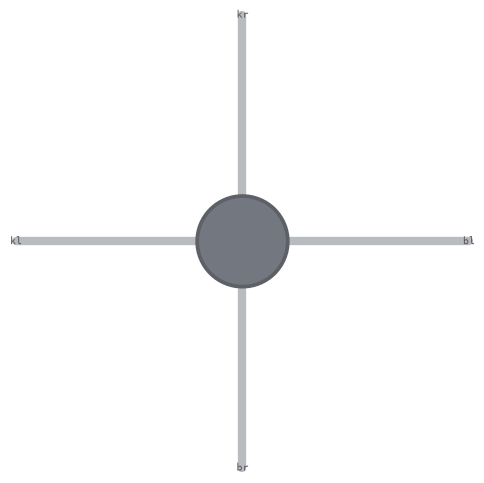

In [53]:
qt_rho.draw()

In [54]:
rho_purification = qtn.tensor_core.tensor_split(
    qt_rho,
    left_inds=['kl', 'kr'],
    method='eigh',
    cutoff=1e-2,
    cutoff_mode='abs',
    absorb=None,
    renorm=False,
    bond_ind='vV'
)

In [55]:
purification_diff = rho_purification.contract(output_inds=qt_rho.inds) - qt_rho
purification_diff_score = (purification_diff & purification_diff.conj()).contract()

In [56]:
purification_diff_score

np.complex128(5.026398369822762e-06+0j)

In [57]:
bra_conjugate_rho = (
    rho_purification.tensors[0]
    & rho_purification.tensors[1]
    & (rho_purification.tensors[2].conj())
)

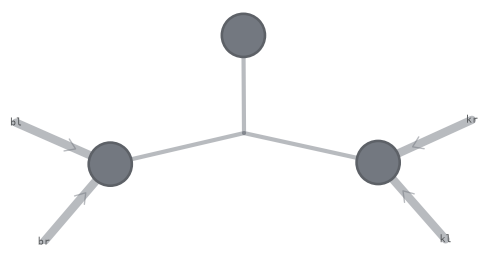

In [58]:
bra_conjugate_rho.draw()

In [59]:
bra_conjugate_rho

TensorNetwork(tensors=3, indices=5)

In [60]:
(
    bra_conjugate_rho
    .tensors[0]
    .unfuse_(
        unfuse_map={'kl': ['kl1', 'kl2'], 'kr': ['kr1', 'kr2']},
        shape_map={
            'kl': (2**2, 2**((num_symmetry_sites//2)-2)),
            'kr': (2**((num_symmetry_sites//2)-2), 2**2)
        }
    )
)

Tensor(shape=(4, 16, 16, 4, 8), inds=('kl1', 'kl2', 'kr1', 'kr2', 'vV'), tags=oset([]), left_inds=('kl1', 'kl2', 'kr1', 'kr2'))

In [61]:
(
    bra_conjugate_rho
    .tensors[2]
    .unfuse_(
        unfuse_map={'bl': ['bl1', 'bl2'], 'br': ['br1', 'br2']},
        shape_map={
            'bl': (2**2, 2**((num_symmetry_sites//2)-2)),
            'br': (2**((num_symmetry_sites//2)-2), 2**2)
        }
    )
)

Tensor(shape=(8, 4, 16, 16, 4), inds=('vV', 'bl1', 'bl2', 'br1', 'br2'), tags=oset([]), left_inds=('bl1', 'bl2', 'br1', 'br2'))

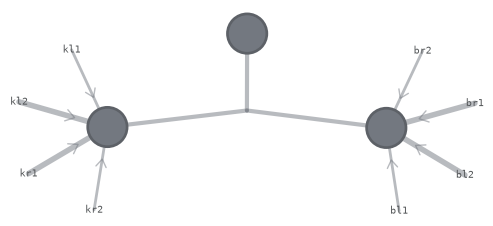

In [62]:
bra_conjugate_rho.draw()

In [63]:
bra_conjugate_rho

TensorNetwork(tensors=3, indices=9)

In [64]:
qu_XX

Tensor(shape=(4, 4), inds=('k', 'b'), tags=oset([]))

In [65]:
qu_XX

Tensor(shape=(4, 4), inds=('k', 'b'), tags=oset([]))

In [66]:
edm = (
    bra_conjugate_rho.reindex(
        {'bl1': 'bbl1', 'bl2': 'bl2', 'br1': 'br1', 'br2': 'bbr2'}
    )
    & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
    & qu_XXXX.reindex({'k': 'kl2', 'b': 'bl2'})
    & qu_XXXX.reindex({'k': 'kr1', 'b': 'br1'})
    & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
)

In [67]:
edm

TensorNetwork(tensors=7, indices=11)

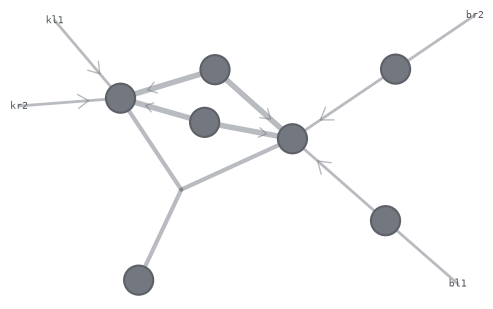

In [68]:
edm.draw()

In [69]:
edm.ind_sizes()

{'kl1': 4,
 'kl2': 16,
 'kr1': 16,
 'kr2': 4,
 'vV': 8,
 'bbl1': 4,
 'bl2': 16,
 'br1': 16,
 'bbr2': 4,
 'bl1': 4,
 'br2': 4}

In [70]:
edm = edm.contract(output_inds=['kl1', 'kr2', 'bl1', 'br2'])

In [71]:
rho_out = get_defect_ops_and_indices_from_density_matrix(qt_rho)

In [72]:
pair = get_restricted_psis_from_purification(qt_rho)
purification_restricted_psi_pairs, purification_diff_score = pair

In [73]:
purification_restricted_psi_output = list()
for psi_0, sv in purification_restricted_psi_pairs:
    purification_restricted_psi_output.append(
        [sv, *get_defect_ops_and_indices_from_restricted_purification_state(psi_0)]
    )

In [74]:
A_opt, A_losses, A_opt_best_loss = get_tensor_network_factorization(qt_rho, rho_purity)

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from complex64 to complex128.
  warnings.warn(


In [75]:
schmidt_decomp_out = schmidt_decompose_tensor_factorization(A_opt)

In [76]:
(
    left_rho_decomp,
    right_rho_decomp,
    left_diff,
    right_diff
) = schmidt_decomp_out

In [77]:
rho_defect_out = get_defect_ops_and_indices_from_factorized_density_matrix(
    qt_rho,
    left_rho_decomp,
    right_rho_decomp,
)

In [78]:
(
    left_right_singular_vals,
    left_defect_op_invariant,
    right_defect_op_invariant,
    rho_defect_ops_overlaps
) = rho_defect_out

In [79]:
restricted_psi_triples = get_restricted_psis(
    left_rho_decomp,
    right_rho_decomp
)

In [80]:
restricted_psi_output = list()
for psi_0, sl, sr in restricted_psi_triples:
    restricted_psi_output.append(
        [sl, sr, *get_defect_ops_and_indices_from_restricted_state(psi_0)]
    )

In [81]:
out = extract_time_reversal_information_after_random_fdlu(quimb_psi, 1)

# Sweep

In [82]:
quimb_psi = get_quimb_psi_from_quspin_psi(psi)

In [84]:
results = extract_time_reversal_information_after_random_fdlu(quimb_psi, 5)

## Analyse results

### Left right rho schmidt values

In [85]:
schmidt_vals = [
    [x for x in l[0] if x > 0.05]
    for l in results
]

In [87]:
num_schmidt_vals = [len(l) for l in schmidt_vals]

In [89]:
Counter(num_schmidt_vals)

Counter({1: 5})

In [91]:
schmidt_vals

[[np.float64(0.30133904761957137)],
 [np.float64(0.2518221480551401)],
 [np.float64(0.2931678790985834)],
 [np.float64(0.3179538993054904)],
 [np.float64(0.32178368620461156)]]

In [92]:
def get_schmidt_vals_ratio(l):
    if len(l) == 1:
        return 0
    else:
        return l[1]/l[0]

In [95]:
schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in schmidt_vals
]

In [96]:
pd.Series(schmidt_val_ratios).describe()

count    5.0
mean     0.0
std      0.0
min      0.0
25%      0.0
50%      0.0
75%      0.0
max      0.0
dtype: float64

### Purification full effective density matrix
Output data:
* left_right_singular_vals
* left_defect_op_invariant
* right_defect_op_invariant
* overlaps
* purification_diff_score

In [97]:
purification_rho_results = [l[1] for l in results]

In [100]:
schmidt_vals = [
    l[0]
    for l in purification_rho_results
]

In [101]:
num_schmidt_vals = [len(l) for l in schmidt_vals]

In [103]:
Counter(num_schmidt_vals)

Counter({4: 2, 2: 1, 3: 1, 6: 1})

In [105]:
schmidt_vals

[array([0.06165031, 0.00244217]),
 array([0.02381993, 0.01081006, 0.00954226]),
 array([0.04648744, 0.0282688 , 0.01389948, 0.00431036, 0.00118012,
        0.00059935]),
 array([0.06843491, 0.05614189, 0.00440838, 0.00197744]),
 array([0.06522193, 0.03641954, 0.00272525, 0.00105817])]

In [106]:
schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in schmidt_vals
]

In [107]:
pd.Series(schmidt_val_ratios).describe()

count    5.000000
mean     0.496059
std      0.287985
min      0.039613
25%      0.453824
50%      0.558394
75%      0.608095
max      0.820369
dtype: float64

In [108]:
left_defect_op_invariants = np.array([
    l[1] for l in purification_rho_results
])

right_defect_op_invariants = np.array([
    l[2] for l in purification_rho_results
])

In [109]:
(
    np.max(np.abs(np.imag(left_defect_op_invariants))),
    np.max(np.abs(np.imag(right_defect_op_invariants)))
)

(np.float64(2.0092998098686365e-08), np.float64(5.551115123125783e-17))

In [110]:
left_defect_op_invariants = np.real(left_defect_op_invariants)
right_defect_op_invariants = np.real(right_defect_op_invariants)

In [111]:
np.round(left_defect_op_invariants, 3)

array([-1.   ,  1.   ,  1.   , -0.999, -1.   ])

In [112]:
np.round(right_defect_op_invariants, 3)

array([-1.   ,  1.   ,  1.   , -0.998, -1.   ])

In [113]:
overlaps = np.array([
    l[3] for l in purification_rho_results
])

In [114]:
np.max(np.abs(np.imag(overlaps)))

np.float64(0.0)

In [115]:
overlaps = np.real(overlaps[:, -1])

In [117]:
overlaps

array([0.24365582, 0.06287546, 0.15699303, 0.20989559, 0.22712785])

In [118]:
defect_results = np.stack(
    (
        overlaps,
        np.real(left_defect_op_invariants),
        np.real(right_defect_op_invariants)
    ),
    axis=-1
)

In [119]:
defect_results = defect_results[defect_results[:, 0].argsort()]

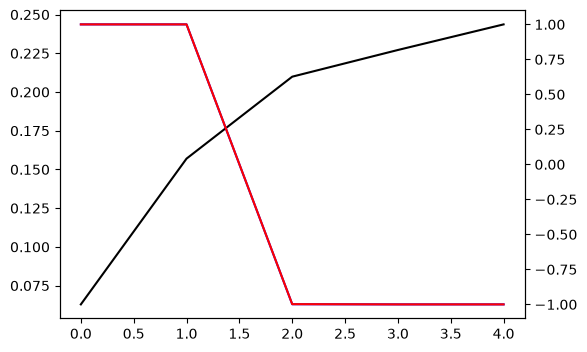

In [120]:
fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.plot(defect_results[:, 0], color='k')
ax2 = ax1.twinx()

ax2.plot(defect_results[:, 1], color='b')
ax2.plot(defect_results[:, 2], color='r')

In [123]:
np.max(np.abs(np.array([l[4] for l in purification_rho_results])))

np.float64(2.0468274117924605e-05)

So this method works, and appears to work well. But why?

In [84]:
purification_rho_results = [l[1] for l in results[1]]

In [85]:
purification_rho_results[0]

array([6.25958981e-02, 5.57095235e-02, 2.62163030e-02, 1.59123367e-02,
       1.39886370e-02, 1.27345709e-02, 7.60175056e-03, 4.29156803e-03,
       9.79672819e-04, 7.58532968e-04, 6.69745020e-04, 7.57109634e-05])

In [86]:
purification_rho_results[-1][0]

array([6.36178634e-02, 4.38832054e-02, 1.73407961e-02, 1.14077170e-02,
       8.01938841e-03, 5.16887730e-03, 3.89574114e-03, 1.77535429e-03,
       2.46023568e-06, 7.86484507e-07, 7.03321441e-07, 3.06112321e-07,
       2.69285877e-08])

In [87]:
schmidt_vals = [
    [x for x in l[0] if x > 0.005]
    for l in purification_rho_results
]

In [88]:
num_schmidt_vals = [len(l) for l in schmidt_vals]

In [89]:
Counter(num_schmidt_vals)

Counter({6: 7, 5: 4, 4: 3, 7: 2, 2: 1, 9: 1, 10: 1, 8: 1})

In [90]:
purification_rho_results[0]

array([6.25958981e-02, 5.57095235e-02, 2.62163030e-02, 1.59123367e-02,
       1.39886370e-02, 1.27345709e-02, 7.60175056e-03, 4.29156803e-03,
       9.79672819e-04, 7.58532968e-04, 6.69745020e-04, 7.57109634e-05])

In [91]:
schmidt_vals

[[np.float64(0.0625958981323562),
  np.float64(0.05570952353351286),
  np.float64(0.026216302993933575),
  np.float64(0.015912336712219165),
  np.float64(0.013988636997645739),
  np.float64(0.012734570922193657),
  np.float64(0.007601750563548353)],
 [np.float64(0.06456065237146703),
  np.float64(0.022940525070703686),
  np.float64(0.021773013327002225),
  np.float64(0.014166255496499315),
  np.float64(0.01096538012737993)],
 [np.float64(0.036871593040985466),
  np.float64(0.030890154697028507),
  np.float64(0.022111434877740685),
  np.float64(0.012779228821922074),
  np.float64(0.011376482274117708),
  np.float64(0.0054149555179044346)],
 [np.float64(0.06617835364109932),
  np.float64(0.05521140042914593),
  np.float64(0.02208980855788966),
  np.float64(0.020411006882858154),
  np.float64(0.010190602380175495),
  np.float64(0.007582141699604678),
  np.float64(0.005386668092870253)],
 [np.float64(0.031170538300495303), np.float64(0.012017786968991983)],
 [np.float64(0.08039720082196487

In [92]:
schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in schmidt_vals
]

In [94]:
pd.Series(schmidt_val_ratios).describe()

count    20.000000
mean      0.591667
std       0.217875
min       0.192831
25%       0.390796
50%       0.632967
75%       0.785994
max       0.889987
dtype: float64

In this case, the results are different!

In [95]:
left_defect_op_invariants = np.array([
    l[1] for l in purification_rho_results
])

right_defect_op_invariants = np.array([
    l[2] for l in purification_rho_results
])

In [96]:
(
    np.max(np.abs(np.imag(left_defect_op_invariants))),
    np.max(np.abs(np.imag(right_defect_op_invariants)))
)

(np.float64(1.5753820581387856e-08), np.float64(0.0002989816084351671))

In [97]:
np.round(left_defect_op_invariants, 3)

array([ 1.+0.j,  1.+0.j, -1.-0.j,  1.-0.j, -1.+0.j,  1.+0.j,  1.+0.j,
       -1.-0.j,  1.-0.j, -1.+0.j, -1.+0.j, -1.+0.j,  1.+0.j,  1.+0.j,
        1.+0.j,  1.+0.j,  1.+0.j, -1.-0.j, -1.-0.j, -1.-0.j])

In [98]:
np.round(right_defect_op_invariants, 3)

array([ 1.+0.j,  1.+0.j, -1.+0.j,  1.+0.j, -1.-0.j,  1.-0.j,  1.-0.j,
       -1.-0.j,  1.+0.j, -1.+0.j, -1.+0.j, -1.-0.j,  1.-0.j,  1.+0.j,
        1.+0.j,  1.+0.j,  1.-0.j, -1.+0.j, -1.+0.j, -1.-0.j])

In [99]:
overlaps = np.array([
    l[3] for l in purification_rho_results
])

In [100]:
np.max(np.abs(np.imag(overlaps)))

np.float64(0.0)

In [101]:
overlaps = np.real(overlaps[:, -1])

In [102]:
pd.Series(overlaps).describe()

count    20.000000
mean      0.188835
std       0.068153
min       0.091391
25%       0.124852
50%       0.184382
75%       0.232051
max       0.313212
dtype: float64

In [103]:
defect_results = np.stack(
    (
        overlaps,
        np.real(left_defect_op_invariants),
        np.real(right_defect_op_invariants)
    ),
    axis=-1
)

In [104]:
defect_results = defect_results[defect_results[:, 0].argsort()]

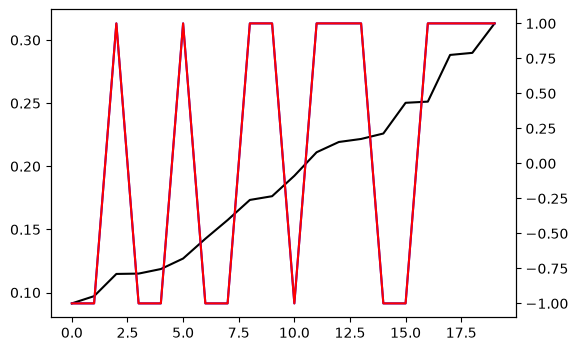

In [105]:
fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.plot(defect_results[:, 0], color='k')
ax2 = ax1.twinx()

ax2.plot(defect_results[:, 1], color='b')
ax2.plot(defect_results[:, 2], color='r')

In [106]:
np.max(np.abs(np.array([l[4] for l in purification_rho_results])))

np.float64(6.0704924906073685e-31)

Overlaps not good here.

### Purificaiton and defect operators on cut states

In [124]:
purification_diffs = [l[2] for l in results]

In [125]:
np.max(np.abs(np.array(purification_diffs)))

np.float64(2.0228040866012625e-30)

In [126]:
purification_cut_state_results = [l[3] for l in results]

Each list contains:
1. Vertical singular value for that eigenvector
2. Left right singular values for resulting effective density matrix.
3. Left invariant
4. Right invariant
5. Overlaps

In [127]:
all_left_indices = [
    l1[2]
    for l in purification_cut_state_results
    for l1 in l
]

In [128]:
all_right_indices = [
    l1[3]
    for l in purification_cut_state_results
    for l1 in l
]

In [129]:
all_left_indices

[np.complex128(-0.9999999999999526-6.264159430058314e-08j),
 np.complex128(-1.0000000000000002+5.551115123125783e-17j),
 np.complex128(-0.9999999999992424+3.1299132130513385e-07j),
 np.complex128(-0.9999999999999998+0j),
 np.complex128(-0.9999999999993346-3.5472279158454967e-07j),
 np.complex128(-1.000000000000001-2.7668145552439682e-11j),
 np.complex128(0.9391213701252299-0.043769307539265445j),
 np.complex128(-0.9999999989971979-1.3052502789878684e-05j),
 np.complex128(0.9999999999999998-2.7755575615628914e-17j),
 np.complex128(0.9999999999999999-2.7755575615628914e-17j),
 np.complex128(1.0000000000000002+5.551115123125783e-17j),
 np.complex128(1+2.7755575615628914e-17j),
 np.complex128(1+0j),
 np.complex128(0.999999999999999-1.186550857568136e-15j),
 np.complex128(0.9999999999999993+2.7755575615628914e-17j),
 np.complex128(0.9999999999999999-1.8041124150158794e-15j),
 np.complex128(0.9999999999999996-5.551115123125783e-17j),
 np.complex128(0.9999999999999997-4.952962900928171e-10j),

In [130]:
all_right_indices

[np.complex128(-0.9999999999999073+7.278422944900775e-08j),
 np.complex128(-0.9999999999999997-2.7755575615628914e-17j),
 np.complex128(-0.9999999999984706-8.728720909401133e-07j),
 np.complex128(-1.0000000000000004+5.551115123125783e-17j),
 np.complex128(-0.9999999999986793+1.2059083921434066e-06j),
 np.complex128(-1.0000000000000007+2.7592639284534926e-10j),
 np.complex128(0.9383486539301338+0.13391884131842113j),
 np.complex128(-0.9999999983506588+2.8795881324594763e-05j),
 np.complex128(1.000000000000001-5.551115123125783e-17j),
 np.complex128(1.0000000000000004+0j),
 np.complex128(1.0000000000000009-5.551115123125783e-17j),
 np.complex128(0.9999999999999991-5.551115123125783e-17j),
 np.complex128(0.9999999999999997+5.551115123125783e-17j),
 np.complex128(0.9999999999999996+0j),
 np.complex128(1.0000000000000002+0j),
 np.complex128(1.0000000000000004+1.6653345369377348e-16j),
 np.complex128(1.0000000000000007-5.551115123125783e-17j),
 np.complex128(1.0000000000000002+1.303405619546

In [131]:
all_overlaps = [
    l1[4][-1]
    for l in purification_cut_state_results
    for l1 in l
]

In [132]:
all_overlaps

[np.float64(0.7536506214550918),
 np.float64(0.7150902286188912),
 np.float64(0.6490024687182459),
 np.float64(0.5940924708033832),
 np.float64(0.4585846157136395),
 np.float64(0.35671674738242287),
 np.float64(0.7332785461059991),
 np.float64(0.7591493937572575),
 np.float64(0.42216950209423076),
 np.float64(0.501894053124991),
 np.float64(0.870989200386464),
 np.float64(0.35428336304725044),
 np.float64(0.48601491927974316),
 np.float64(0.6103200885342683),
 np.float64(0.6000817403901579),
 np.float64(0.28509644508313015),
 np.float64(0.7365684789229945),
 np.float64(0.486676265276501),
 np.float64(0.3134059612508149),
 np.float64(0.4413022980938556),
 np.float64(0.5401954934056669),
 np.float64(0.5424802661685357),
 np.float64(0.3159023966864353),
 np.float64(0.2199729693232721),
 np.float64(0.5170075322736022),
 np.float64(0.7483718999064686),
 np.float64(0.5773558910091845),
 np.float64(0.4436077904494821),
 np.float64(0.433507369854046),
 np.float64(0.4348442641808694),
 np.float

In [116]:
purification_diffs = [l[2] for l in results[1]]

In [117]:
np.max(np.abs(np.array(purification_diffs)))

np.float64(6.0704924906073685e-31)

In [118]:
purification_cut_state_results = [l[3] for l in results[1]]

In [119]:
all_left_indices = [
    l1[2]
    for l in purification_cut_state_results
    for l1 in l
]

In [120]:
all_right_indices = [
    l1[3]
    for l in purification_cut_state_results
    for l1 in l
]

In [121]:
all_left_indices

[np.complex128(0.8022927619499768-0.0882938524099025j),
 np.complex128(0.3314686662732417+0.032312669933784566j),
 np.complex128(-0.9999976240950836+0.0006614306104607282j),
 np.complex128(0.43764647348745056-0.008962784354247619j),
 np.complex128(0.9889543437603696-0.04813830315196199j),
 np.complex128(0.9999999983100759+1.7176503540314303e-05j),
 np.complex128(-0.9999999959745194-5.090337368285347e-07j),
 np.complex128(0.2589909611312373-0.007536347064579951j),
 np.complex128(-0.992992633929125-7.068100374653732e-05j),
 np.complex128(1.0000000000000009+2.1485146994848492e-11j),
 np.complex128(1.0000000000000002+0j),
 np.complex128(1+3.6404323999761345e-11j),
 np.complex128(1+1.1102230246251565e-16j),
 np.complex128(0.9999999999999994+5.551115123125783e-17j),
 np.complex128(0.9999999999984228-1.1927040882708795e-07j),
 np.complex128(0.9999999999999991-2.1007029449293668e-10j),
 np.complex128(-0.13819309643081812-0.2734310436032523j),
 np.complex128(0.9999999875070991+9.068537281609057

In [122]:
all_right_indices

[np.complex128(0.7992676999238524-0.014517336739903686j),
 np.complex128(0.2731138301079493-0.025720576619090774j),
 np.complex128(-0.9999963223257573-0.0007093180779610408j),
 np.complex128(0.35539686795186914-0.0002159020763115721j),
 np.complex128(0.9876686546374353+0.04976463703667067j),
 np.complex128(0.9999999970847786-3.328088834148035e-05j),
 np.complex128(-0.9999999942904654-1.9201546227476385e-06j),
 np.complex128(0.19681850226043385+0.020113191315238976j),
 np.complex128(-0.9930131378584662-0.0005185554329948938j),
 np.complex128(1+4.726996571946529e-11j),
 np.complex128(0.9999999999999999+5.551115123125783e-17j),
 np.complex128(0.9999999999999991-8.094586112505908e-11j),
 np.complex128(0.9999999999999999-1.6653345369377348e-16j),
 np.complex128(1.0000000000000007+0j),
 np.complex128(0.9999999999962683-1.5299804145829654e-08j),
 np.complex128(0.9999999999999996+7.852624106519102e-11j),
 np.complex128(-0.13600553058084813+0.27562812063154746j),
 np.complex128(0.99999997915090

In [123]:
all_overlaps = [
    l1[4][-1]
    for l in purification_cut_state_results
    for l1 in l
]

In [124]:
all_overlaps

[np.float64(0.5140512104083126),
 np.float64(0.6508255515883603),
 np.float64(0.712682055907286),
 np.float64(0.6467418556069708),
 np.float64(0.6776628134556875),
 np.float64(0.815205261169617),
 np.float64(0.7710246674506872),
 np.float64(0.6491712285952056),
 np.float64(0.48898762131105145),
 np.float64(0.8807106062095282),
 np.float64(0.7298953961116352),
 np.float64(0.5660076861255049),
 np.float64(0.7073405047615197),
 np.float64(0.9109186443122371),
 np.float64(0.5112699825443592),
 np.float64(0.37916066521219005),
 np.float64(0.5666924300249605),
 np.float64(0.4389925173797987),
 np.float64(0.5253082208373943),
 np.float64(0.673146640602009),
 np.float64(0.5839732736118659),
 np.float64(0.462535288819101),
 np.float64(0.41826526262982827),
 np.float64(0.48865526387700636),
 np.float64(0.3426914537084993),
 np.float64(0.6812416144544349),
 np.float64(0.6404262701087015),
 np.float64(0.8353063704240624),
 np.float64(0.667013609537176),
 np.float64(0.7483836101310567),
 np.float64

Results all over the place here.

### Tensor network factorizations

In [133]:
factorization_loss_curves = [l[4] for l in results]

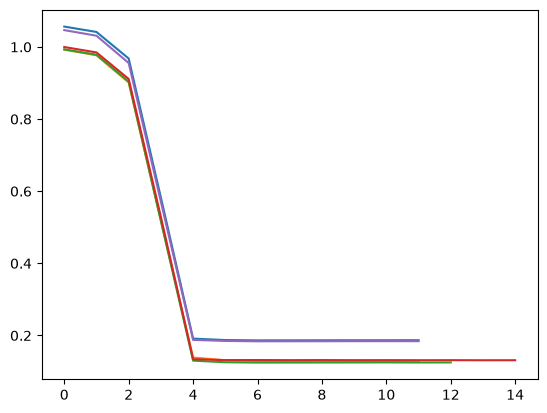

In [134]:
for l in factorization_loss_curves:
    plt.plot(l);

In [135]:
best_loss = [min(l) for l in factorization_loss_curves]

In [136]:
pd.Series(best_loss).describe()

count    5.000000
mean     0.151183
std      0.031109
min      0.124855
25%      0.129416
50%      0.131347
75%      0.183843
max      0.186455
dtype: float64

In [137]:
left_loss = np.array([l[6] for l in results])
right_loss = np.array([l[7] for l in results])

In [138]:
(
    np.max(np.abs(np.imag(left_loss))),
    np.max(np.abs(np.imag(right_loss)))
)

(np.float32(0.0), np.float32(0.0))

In [139]:
left_loss = np.real(left_loss)
right_loss = np.real(right_loss)

In [140]:
np.max(left_loss), np.max(right_loss)

(np.float32(1.0066284e-12), np.float32(1.1038318e-12))

In [133]:
factorization_loss_curves = [l[4] for l in results[1]]

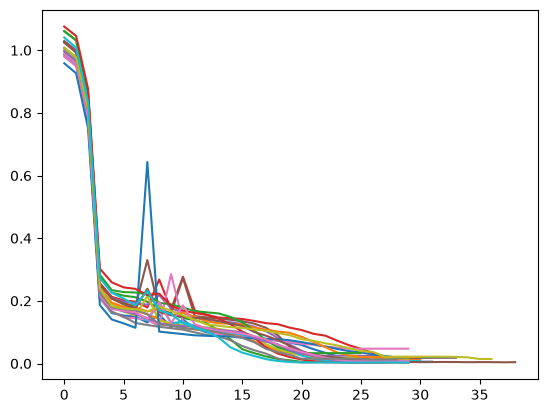

In [134]:
for l in factorization_loss_curves:
    plt.plot(l);

In [135]:
best_loss = [min(l) for l in factorization_loss_curves]

In [136]:
pd.Series(best_loss).describe()

count    20.000000
mean      0.013674
std       0.011400
min       0.002941
25%       0.005013
50%       0.011662
75%       0.018587
max       0.047151
dtype: float64

In [137]:
left_loss = np.array([l[6] for l in results[1]])
right_loss = np.array([l[7] for l in results[1]])

In [138]:
(
    np.max(np.abs(np.imag(left_loss))),
    np.max(np.abs(np.imag(right_loss)))
)

(np.float32(0.0), np.float32(0.0))

In [139]:
left_loss = np.real(left_loss)
right_loss = np.real(right_loss)

In [140]:
np.max(left_loss), np.max(right_loss)

(np.float32(1.6048764e-12), np.float32(2.3219e-12))

### Factorized full effective density matrix

In [143]:
schmidt_vals = [
    l[8]
    for l in results
]

In [144]:
schmidt_vals

[array([5.65800035e-02, 5.81380139e-04, 4.12583288e-04, 3.52669109e-04,
        3.45475183e-04, 2.77554996e-04, 2.45351597e-04, 2.29518623e-04,
        1.63920430e-04, 1.35945129e-04, 1.34520763e-04, 9.08452097e-05,
        6.90410059e-05, 3.32058885e-05, 2.18699006e-05, 9.29368231e-06]),
 array([3.40725011e-02, 4.36864874e-04, 3.88777708e-04, 2.91896380e-04,
        2.73472470e-04, 2.58988834e-04, 1.96462994e-04, 1.92981437e-04,
        1.61131011e-04, 1.51178752e-04, 1.02165233e-04, 7.34787819e-05,
        7.33940978e-05, 5.41860390e-05, 4.30499984e-05, 4.41883156e-06]),
 array([6.16085598e-02, 6.11300837e-04, 4.05868154e-04, 3.85453969e-04,
        2.87614216e-04, 2.17958769e-04, 2.13598066e-04, 1.60741236e-04,
        1.56860874e-04, 1.16853490e-04, 1.01404529e-04, 8.29499999e-05,
        5.15297281e-05, 3.26939760e-05, 2.41561044e-05, 6.13662999e-06]),
 array([2.02765459e-02, 2.12119962e-03, 1.47469392e-03, 1.27391898e-03,
        1.03353223e-03, 9.87300529e-04, 7.50712236e-04, 6.

In [145]:
schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in schmidt_vals
]

In [146]:
pd.Series(schmidt_val_ratios).describe()

count    5.000000
mean     0.029846
std      0.041812
min      0.009922
25%      0.010275
50%      0.011597
75%      0.012822
max      0.104613
dtype: float64

In [147]:
left_invariants = [l[9] for l in results]
right_invariants = [l[10] for l in results]

In [148]:
left_invariants

[np.complex128(1.0000000000000178+2.1365861024857935e-09j),
 np.complex128(0.999999999999968-4.0458319194858205e-09j),
 np.complex128(1.0000000000000084-1.4941458070794056e-09j),
 np.complex128(1.000000000000008-4.998630687147454e-08j),
 np.complex128(1.0000000000000044+1.9956534258458447e-08j)]

In [149]:
right_invariants

[np.complex128(1.0000000000000147+7.274988667038684e-10j),
 np.complex128(0.9999999999999258-7.460428635974736e-09j),
 np.complex128(0.9999999999999993-3.437095852376615e-08j),
 np.complex128(0.9999999999999936+9.93180676589489e-10j),
 np.complex128(0.9999999999999866-5.321498262877977e-08j)]

In [150]:
overlaps = np.array([l[11][-1] for l in results])

In [151]:
np.max(np.abs(np.imag(overlaps)))

np.float64(0.0)

In [152]:
overlaps = np.real(overlaps)

In [153]:
pd.Series(overlaps).describe()

count    5.000000
mean     0.105124
std      0.039430
min      0.053363
25%      0.074092
50%      0.119687
75%      0.134961
max      0.143519
dtype: float64

In [154]:
defect_results = np.stack(
    (
        overlaps,
        np.real(left_invariants),
        np.real(right_invariants)
    ),
    axis=-1
)

In [155]:
defect_results = defect_results[defect_results[:, 0].argsort()]

(-1.05, 1.05)

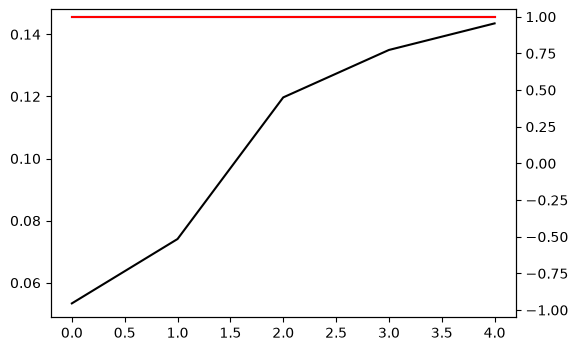

In [156]:
fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.plot(defect_results[:, 0], color='k')
ax2 = ax1.twinx()

ax2.plot(defect_results[:, 1], color='b')
ax2.plot(defect_results[:, 2], color='r')

ax2.set_ylim(-1.05, 1.05)

In [157]:
schmidt_vals = [
    [x for x in l[8] if x > 0.005]
    for l in results[1]
]

In [158]:
schmidt_vals

[[np.float64(0.07172796053824335),
  np.float64(0.03756890060255816),
  np.float64(0.036394258165869095),
  np.float64(0.025035027944144913)],
 [np.float64(0.0422536348526984), np.float64(0.017996120362779647)],
 [np.float64(0.04667779755138709),
  np.float64(0.022112392792170837),
  np.float64(0.005442721089933723)],
 [np.float64(0.03647334122254381),
  np.float64(0.02490702122550008),
  np.float64(0.022693163014015815),
  np.float64(0.013451564173818875),
  np.float64(0.011766172228092368),
  np.float64(0.00926663625294284),
  np.float64(0.006880546399168546),
  np.float64(0.005351488323735786)],
 [np.float64(0.04451349132788928),
  np.float64(0.014247777210709177),
  np.float64(0.0070880951371632165),
  np.float64(0.005089213273926741)],
 [np.float64(0.10852035482303675),
  np.float64(0.05613278808326403),
  np.float64(0.00700970928229939)],
 [np.float64(0.03840682455174624),
  np.float64(0.018116820306318983),
  np.float64(0.006750214547408409)],
 [np.float64(0.045838263278948854),

In [159]:
num_schmidt_vals = [len(l) for l in schmidt_vals]

In [160]:
Counter(num_schmidt_vals)

Counter({3: 7, 4: 4, 5: 4, 7: 2, 2: 1, 8: 1, 6: 1})

In [161]:
schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in schmidt_vals
]

In [162]:
pd.Series(schmidt_val_ratios).describe()

count    20.000000
mean      0.553762
std       0.170616
min       0.194887
25%       0.447440
50%       0.539519
75%       0.669832
max       0.955737
dtype: float64

A bit more entangled...

In [163]:
left_invariants = [l[9] for l in results[1]]
right_invariants = [l[10] for l in results[1]]

In [164]:
left_invariants

[np.complex128(0.9999999999999969-8.927428171712215e-09j),
 np.complex128(0.9999999999999886+1.2169254520744133e-08j),
 np.complex128(-0.99999999999975-7.047396988202337e-08j),
 np.complex128(0.99999999999998-3.7506206473914006e-09j),
 np.complex128(1.0000000000000002-2.3491067452363623e-08j),
 np.complex128(0.9999999999999971+0j),
 np.complex128(1+3.402009064040756e-08j),
 np.complex128(-0.9999999999999174-5.015363332971923e-10j),
 np.complex128(0.9999999999999964-2.2851869757589682e-08j),
 np.complex128(1.000000000000009+8.279731067428742e-10j),
 np.complex128(0.9999999999999797+2.2433545299183066e-09j),
 np.complex128(0.9999999999999012+5.1021916969151704e-08j),
 np.complex128(1.0000000000000013-2.0816681711721685e-17j),
 np.complex128(0.9999999999999973+8.854376468137026e-10j),
 np.complex128(0.999999999999659-6.938893903907228e-18j),
 np.complex128(0.9999999999999991-1.9942094364733265e-09j),
 np.complex128(0.9999999999999847+2.7755575615628914e-17j),
 np.complex128(0.999999999999

In [165]:
right_invariants

[np.complex128(1.0000000000000087+8.213796448552912e-10j),
 np.complex128(0.9999999999999981+1.5790590363051749e-09j),
 np.complex128(-1.00000000000001-6.141168407136632e-10j),
 np.complex128(0.9999999999999135+1.0253696725026629e-08j),
 np.complex128(0.9999999999997861+1.520387721276606e-08j),
 np.complex128(0.999999999999998-4.4970114437825615e-09j),
 np.complex128(1.0000000000000044-1.8964527725984226e-09j),
 np.complex128(-0.9999999999999465+2.11899109925362e-08j),
 np.complex128(0.9999999999998781+4.6377956669507725e-08j),
 np.complex128(0.9999999999999059+2.3320706962759452e-08j),
 np.complex128(0.9999999999999876-1.0363073177366289e-09j),
 np.complex128(1.0000000000000022-2.5583710427934392e-08j),
 np.complex128(0.9999999999998997-1.601562471531537e-08j),
 np.complex128(0.9999999999999974+7.79929398841972e-10j),
 np.complex128(0.9999999999993375+9.01985801743388e-08j),
 np.complex128(0.9999999999998338-7.354683917437654e-08j),
 np.complex128(0.9999999999999895+5.551115123125783e

In [166]:
overlaps = np.array([l[11][-1] for l in results[1]])

In [167]:
np.max(np.abs(np.imag(overlaps)))

np.float64(0.0)

In [168]:
overlaps = np.real(overlaps)

In [169]:
pd.Series(overlaps).describe()

count    20.000000
mean      0.161742
std       0.088213
min       0.058823
25%       0.102269
50%       0.133972
75%       0.183287
max       0.409251
dtype: float64

In [170]:
defect_results = np.stack(
    (
        overlaps,
        np.real(left_invariants),
        np.real(right_invariants)
    ),
    axis=-1
)

In [171]:
defect_results = defect_results[defect_results[:, 0].argsort()]

(-1.05, 1.05)

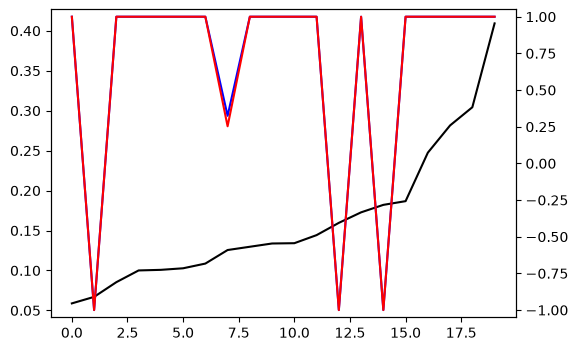

In [172]:
fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.plot(defect_results[:, 0], color='k')
ax2 = ax1.twinx()

ax2.plot(defect_results[:, 1], color='b')
ax2.plot(defect_results[:, 2], color='r')

ax2.set_ylim(-1.05, 1.05)

### Factorized cut states

In [157]:
factorized_cut_state_results = [l[12] for l in results]

In [158]:
factorized_cut_state_results[0]

[[np.float32(0.29703233),
  np.float32(0.29978383),
  array([1.05819556e-01, 2.12694467e-03, 1.90225112e-03, 1.54865941e-03,
         1.35281307e-03, 1.27585957e-03, 8.56076763e-04, 7.23361133e-04,
         5.73207730e-04, 4.92392465e-04, 4.12103052e-04, 3.36229842e-04,
         2.59870704e-04, 9.79372040e-05, 7.51273138e-05, 3.32509306e-05]),
  np.complex128(1.00000011920929+3.725290242950763e-09j),
  np.complex128(0.9999998211860657-4.65661288695518e-09j),
  np.float64(0.2980338186642982)],
 [np.float32(0.29703233),
  np.float32(0.2961546),
  array([7.79710593e-02, 1.94614539e-03, 1.89441897e-03, 1.76549056e-03,
         1.36513268e-03, 1.31879604e-03, 8.44977556e-04, 7.60613434e-04,
         6.29732167e-04, 4.97416405e-04, 4.13411702e-04, 2.64285354e-04,
         1.96611465e-04, 1.04303462e-04, 8.38840031e-05, 7.50511835e-05]),
  np.complex128(0.9999999552965161+1.0710209608078003e-08j),
  np.complex128(0.999999925494194+4.190951592708547e-09j),
  np.float64(0.22579456083990865)],
 

In [159]:
all_left_indices = [
    l1[3]
    for l in factorized_cut_state_results
    for l1 in l
]

In [160]:
all_left_indices

[np.complex128(1.00000011920929+3.725290242950763e-09j),
 np.complex128(0.9999999552965161+1.0710209608078003e-08j),
 np.complex128(1.0000001192092893-9.313224913487517e-10j),
 np.complex128(0.9999997913837433+2.8870999868590985e-08j),
 np.complex128(0.9999998211860657+6.193295096212914e-08j),
 np.complex128(1.0000001490116117+2.305023368009973e-08j),
 np.complex128(0.9999998360872262-7.45058045814595e-09j),
 np.complex128(0.9999999552965153-9.313225704521422e-09j),
 np.complex128(0.9999999701976776-1.3504177331924438e-08j),
 np.complex128(1.0000000596046439-2.7939677481325642e-09j),
 np.complex128(1.00000025331974+6.98491936512724e-09j),
 np.complex128(1.0000000149011603-7.45058058304604e-09j),
 np.complex128(1.000000074505806+5.587935447692871e-09j),
 np.complex128(1.0000000894069676-1.5832483768463135e-08j),
 np.complex128(0.9999997764825824-1.955777406692505e-08j),
 np.complex128(0.999999940395355+6.519257966797198e-09j),
 np.complex128(1.0000001639127727+1.1525116749844244e-08j),


In [161]:
all_right_indices = [
    l1[4]
    for l in factorized_cut_state_results
    for l1 in l
]

In [162]:
all_right_indices

[np.complex128(0.9999998211860657-4.65661288695518e-09j),
 np.complex128(0.999999925494194+4.190951592708547e-09j),
 np.complex128(1.0000000298023224+1.2107193553267948e-08j),
 np.complex128(1.000000014901161+2.002343542015228e-08j),
 np.complex128(0.9999998956918725-8.38190321317267e-09j),
 np.complex128(0.9999999850988391-4.889443461220111e-09j),
 np.complex128(1.0000001937150946-1.3969838619232178e-08j),
 np.complex128(1.000000149011612+4.097819325532548e-08j),
 np.complex128(0.9999999105930323+7.450580680190555e-09j),
 np.complex128(0.9999999850988383-9.546056396747549e-09j),
 np.complex128(1.0000000894069674-1.676380642634534e-08j),
 np.complex128(1.0000000745058055-5.587935454631765e-09j),
 np.complex128(1.0000001192092907+9.31322568370474e-09j),
 np.complex128(0.9999999850988389-2.7706846553177122e-08j),
 np.complex128(0.9999997764825818-1.1175870853752379e-08j),
 np.complex128(0.9999998062849043-1.9557774011413898e-08j),
 np.complex128(1.0000000149011612-4.656612873077393e-10j)

In [163]:
all_overlaps = [
    l1[4][-1]
    for l in purification_cut_state_results
    for l1 in l
]

In [164]:
all_overlaps

[np.float64(0.7536506214550918),
 np.float64(0.7150902286188912),
 np.float64(0.6490024687182459),
 np.float64(0.5940924708033832),
 np.float64(0.4585846157136395),
 np.float64(0.35671674738242287),
 np.float64(0.7332785461059991),
 np.float64(0.7591493937572575),
 np.float64(0.42216950209423076),
 np.float64(0.501894053124991),
 np.float64(0.870989200386464),
 np.float64(0.35428336304725044),
 np.float64(0.48601491927974316),
 np.float64(0.6103200885342683),
 np.float64(0.6000817403901579),
 np.float64(0.28509644508313015),
 np.float64(0.7365684789229945),
 np.float64(0.486676265276501),
 np.float64(0.3134059612508149),
 np.float64(0.4413022980938556),
 np.float64(0.5401954934056669),
 np.float64(0.5424802661685357),
 np.float64(0.3159023966864353),
 np.float64(0.2199729693232721),
 np.float64(0.5170075322736022),
 np.float64(0.7483718999064686),
 np.float64(0.5773558910091845),
 np.float64(0.4436077904494821),
 np.float64(0.433507369854046),
 np.float64(0.4348442641808694),
 np.float

In [185]:
factorized_cut_state_results = [l[12] for l in results[1]]

In [186]:
factorized_cut_state_results[0]

[np.float32(0.45905328),
 np.float32(0.71258754),
 array([2.67683966e-01, 2.53129282e-01, 1.29209143e-01, 6.46224618e-02,
        9.51456462e-03, 5.42501925e-03, 5.37509686e-03, 3.31811762e-03,
        2.40548596e-03, 1.27249425e-03, 1.12635914e-03, 1.75043650e-04,
        1.22364507e-04, 3.64522627e-05, 1.94802238e-05, 1.61687100e-05]),
 np.complex128(0.9394132855487953-0.023173629060866494j),
 np.complex128(0.9504423400026697-0.0022642189482050823j),
 np.float64(0.6351718826124023)]

In [187]:
all_left_indices = [
    l1[3]
    for l in factorized_cut_state_results
    for l1 in l
]

In [188]:
all_left_indices

[np.complex128(0.9394132855487953-0.023173629060866494j),
 np.complex128(-0.6229506690665119-0.0859422920034044j),
 np.complex128(0.9999999999903668-1.8303276677622549e-07j),
 np.complex128(0.9999997983396645+1.053783270310582e-06j),
 np.complex128(-0.0367803644602378-0.12807830523734356j),
 np.complex128(-0.051419055538770075+0.09758943834437335j),
 np.complex128(1.0000001862645145+4.364298644699005e-10j),
 np.complex128(1.0000001490116106-2.260005405041454e-09j),
 np.complex128(-0.9480339533116853-0.0053938937097443365j),
 np.complex128(-0.9968058056226845+0.0008231958608424517j),
 np.complex128(-0.9994969900543983-0.00012543958362554175j),
 np.complex128(-0.9999471330579962-0.00025332659488241926j),
 np.complex128(-0.9934670040004644-0.002563591743935556j),
 np.complex128(-0.9997123276833634-0.00016790880508201975j),
 np.complex128(0.9983913115115857+0.0018721854648726666j),
 np.complex128(0.9999988588054015+9.64031075081917e-06j),
 np.complex128(-1.0000002384185789-1.11022302462515

In [189]:
all_right_indices = [
    l1[4]
    for l in factorized_cut_state_results
    for l1 in l
]

In [190]:
all_right_indices

[np.complex128(0.9504423400026697-0.0022642189482050823j),
 np.complex128(-0.6593216988552341+0.07012235918279336j),
 np.complex128(1.000000089389362+1.1381624132750234e-07j),
 np.complex128(0.9999999358189384-4.506343721309702e-06j),
 np.complex128(-0.2517256866710491+0.021049526623018233j),
 np.complex128(-0.31695555967914857+0.08898052646896254j),
 np.complex128(1.0000001061707735-1.8345222840832065e-08j),
 np.complex128(1.0000000204890913+1.1861719384498315e-08j),
 np.complex128(-0.9410873387135408+0.007298202725983888j),
 np.complex128(-0.9963149605485104-0.0008100114344348763j),
 np.complex128(-0.9993800783873648+0.0002492243298668484j),
 np.complex128(-0.99993516469068+0.00027465291636608047j),
 np.complex128(-0.9916793172099141+0.003292443877327293j),
 np.complex128(-0.9996313894882871+0.00020308291129395029j),
 np.complex128(0.9979946760759283-0.0020299794383595304j),
 np.complex128(0.9999986288922942+2.9431567083459953e-06j),
 np.complex128(-1.0000000596046446+7.4505806524349

In [191]:
all_overlaps = [
    l1[4][-1]
    for l in purification_cut_state_results
    for l1 in l
]

In [192]:
all_overlaps

[np.float64(0.5140512104083126),
 np.float64(0.6508255515883603),
 np.float64(0.712682055907286),
 np.float64(0.6467418556069708),
 np.float64(0.6776628134556875),
 np.float64(0.815205261169617),
 np.float64(0.7710246674506872),
 np.float64(0.6491712285952056),
 np.float64(0.48898762131105145),
 np.float64(0.8807106062095282),
 np.float64(0.7298953961116352),
 np.float64(0.5660076861255049),
 np.float64(0.7073405047615197),
 np.float64(0.9109186443122371),
 np.float64(0.5112699825443592),
 np.float64(0.37916066521219005),
 np.float64(0.5666924300249605),
 np.float64(0.4389925173797987),
 np.float64(0.5253082208373943),
 np.float64(0.673146640602009),
 np.float64(0.5839732736118659),
 np.float64(0.462535288819101),
 np.float64(0.41826526262982827),
 np.float64(0.48865526387700636),
 np.float64(0.3426914537084993),
 np.float64(0.6812416144544349),
 np.float64(0.6404262701087015),
 np.float64(0.8353063704240624),
 np.float64(0.667013609537176),
 np.float64(0.7483836101310567),
 np.float64

# Conclusions
It looks like we need a larger system in order to explore these longer correlations.

# Old code

## Apply random symmetries test

In [13]:
psi = groundstates[0]

In [15]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [16]:
print(basis)

reference states: 
array index   /   Fock state   /   integer repr. 
     0.  |1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1>  65535 
     1.  |1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0>  65534 
     2.  |1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1>  65533 
     3.  |1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0>  65532 
     4.  |1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1>  65531 
     5.  |1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0>  65530 
     6.  |1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1>  65529 
     7.  |1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0>  65528 
     8.  |1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1>  65527 
     9.  |1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0>  65526 
    10.  |1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1>  65525 
    11.  |1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0>  65524 
    12.  |1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1>  65523 
    13.  |1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0>  65522 
    14.  |1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1>  65521 
    15.  |1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0>  65520 
    16.  |1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1>  65519 
    17.  |1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0>  65518 
    18.  |1 1

In [14]:
psi

array([[ 3.90582915e-03+5.73388357e-05j],
       [-5.73388357e-05+3.90582915e-03j],
       [-5.73388357e-05+3.90582915e-03j],
       ...,
       [ 5.73388357e-05-3.90582915e-03j],
       [ 5.73388357e-05-3.90582915e-03j],
       [ 3.90582915e-03+5.73388357e-05j]], shape=(65536, 1))

In [18]:
np.arange(16).reshape((2,)*4)

array([[[[ 0,  1],
         [ 2,  3]],

        [[ 4,  5],
         [ 6,  7]]],


       [[[ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15]]]])

In [22]:
qu_psi = qtn.Tensor(
    psi[::-1].reshape((2,)*num_sites),
    inds=[f'k{i}' for i in range(num_sites)]
)

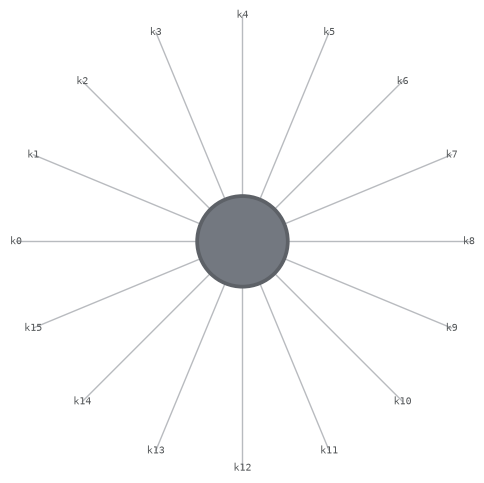

In [23]:
qu_psi.draw()

In [24]:
qu_psi

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2), inds=('k0', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12', 'k13', 'k14', 'k15'), tags=oset([]))

In [50]:
u = qu.gen.rand.rand_uni(4)

In [51]:
np.round(u, 3)

[[ 0.21 -0.234j  0.652+0.471j -0.069+0.35j   0.352-0.063j]
 [ 0.135-0.189j  0.028+0.158j  0.161-0.832j  0.336-0.297j]
 [-0.104-0.254j -0.546-0.004j -0.043+0.381j  0.424-0.548j]
 [-0.657-0.583j -0.056+0.163j  0.049-0.071j  0.048+0.434j]]

In [52]:
np.round(u @ u.T.conj(), 3)

[[ 1.+0.j -0.-0.j -0.-0.j -0.+0.j]
 [-0.+0.j  1.+0.j  0.-0.j  0.-0.j]
 [-0.+0.j  0.+0.j  1.+0.j  0.-0.j]
 [-0.-0.j  0.+0.j  0.+0.j  1.+0.j]]

In [28]:
type(u)

quimb.core.qarray

In [29]:
qu_u = qtn.Tensor(
    qu.gen.rand.rand_uni(4).reshape((2,)*4),
    inds=['k1', 'k2', 'b1', 'b2']
)

In [30]:
out_qu_psi = (
    qu_psi.reindex({'k1': 'b1', 'k2': 'b2'})
    & qu_u
)

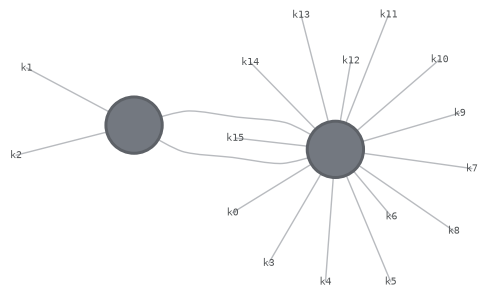

In [32]:
out_qu_psi.draw()

In [33]:
out_qu_psi.contract(inplace=True)

TensorNetwork(tensors=1, indices=16)

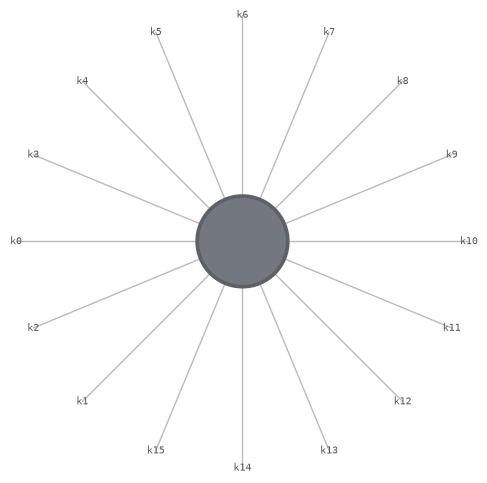

In [34]:
out_qu_psi.draw()

In [37]:
X = out_qu_psi.tensors[0].data.reshape((-1))[::-1]

In [38]:
X.shape

(65536,)

In [39]:
X

array([-0.00220717+0.00142551j, -0.00310542-0.00063017j,
        0.00343488-0.0033824j , ...,  0.00310542+0.00063017j,
       -0.00343488+0.0033824j , -0.00174788+0.00421859j], shape=(65536,))

In [54]:
# Warning, likely making assupmtions about shape of psi, number of sites being even here etc.
def apply_haar_random_fdlu_to_quspin_state(psi):
    qu_psi = qtn.Tensor(
        psi[::-1].reshape((2,)*num_sites),
        inds=[f'k{i}' for i in range(num_sites)]
    )

    for delta in [0,1]:
        for i in range(num_sites//2):
            site_1 = ((2*i)+delta)%num_sites
            site_2 = ((2*i)+1+delta)%num_sites
    
            qu_u = qtn.Tensor(
                qu.gen.rand.rand_uni(4).reshape((2,)*4),
                inds=[f'k{site_1}', f'k{site_2}', f'b{site_1}', f'b{site_2}']
            )
    
            qu_psi = (
                qu_psi.reindex(
                    {f'k{site_1}':  f'b{site_1}', f'k{site_2}': f'b{site_2}'}
                )
                & qu_u
            )
            qu_psi.contract(inplace=True)

    out_psi = qu_psi.tensors[0].data.reshape((-1))[::-1]

    return out_psi

In [64]:
test_psis = [
    apply_haar_random_fdlu_to_quspin_state(psi) 
    for _ in range(100)
]

In [67]:
diffs = list()

for psi_rand in test_psis:
    overlap = np.dot(psi.conj()[:, 0], psi_rand)
    diffs.append(overlap)

diffs = np.array(diffs)

In [69]:
np.round(diffs, 3)

array([ 0.001-0.003j, -0.   -0.002j, -0.   -0.001j, -0.004+0.005j,
        0.001-0.003j, -0.   +0.j   ,  0.01 +0.002j, -0.   -0.j   ,
        0.003-0.001j,  0.001+0.001j,  0.001+0.j   ,  0.   +0.j   ,
       -0.001-0.j   ,  0.002-0.001j, -0.   -0.001j, -0.001-0.001j,
       -0.   -0.j   ,  0.   -0.j   ,  0.001-0.j   , -0.   -0.j   ,
        0.001-0.j   ,  0.004+0.004j, -0.001-0.003j, -0.001-0.004j,
        0.003-0.001j, -0.007+0.013j, -0.   -0.001j, -0.   -0.001j,
        0.   -0.j   , -0.001-0.001j,  0.001-0.002j, -0.001-0.j   ,
       -0.   -0.j   ,  0.   +0.002j,  0.   +0.001j, -0.   -0.002j,
        0.002-0.001j,  0.001+0.001j,  0.002+0.005j,  0.   -0.001j,
       -0.003-0.j   , -0.001+0.004j, -0.002-0.002j, -0.   -0.j   ,
       -0.   +0.j   ,  0.003+0.006j, -0.   +0.j   , -0.002-0.001j,
       -0.001+0.002j, -0.   +0.004j, -0.004+0.004j,  0.002+0.j   ,
        0.002-0.002j, -0.   +0.j   , -0.002+0.002j,  0.   -0.j   ,
       -0.   +0.001j, -0.002+0.001j, -0.001-0.001j,  0.001-0.0

In [70]:
from itertools import combinations

In [71]:
diffs = list()

for psi_1, psi_2 in combinations(test_psis, 2):
    overlap = np.dot(psi_1.conj(), psi_2)
    diffs.append(overlap)

diffs = np.array(diffs)

In [72]:
np.abs(diffs)

array([0.00134098, 0.00037768, 0.00015354, ..., 0.00254437, 0.00191283,
       0.00027508], shape=(4950,))

## Generate and test random unitaries respecting $XK$ symmetry

In [87]:
o = ortho_group.rvs(4)

In [88]:
o

array([[ 0.38102352, -0.79409578,  0.27917744, -0.38248259],
       [ 0.77824464,  0.51678111, -0.07115791, -0.34958419],
       [-0.44998244,  0.28812547,  0.50418709, -0.67845036],
       [ 0.21603739,  0.13904278,  0.81412031,  0.52077161]])

In [89]:
np_H = np.pow(2, -1/2)*np.array([
    [1,1],
    [1,-1]
])

In [90]:
np_W = np.kron(np_H, np_H) @ np.diag([1, 1j, 1j, 1])

In [91]:
np_W

array([[ 0.5+0.j ,  0. +0.5j,  0. +0.5j,  0.5+0.j ],
       [ 0.5+0.j ,  0. -0.5j,  0. +0.5j, -0.5+0.j ],
       [ 0.5+0.j ,  0. +0.5j,  0. -0.5j, -0.5+0.j ],
       [ 0.5+0.j ,  0. -0.5j,  0. -0.5j,  0.5+0.j ]])

In [92]:
u = np_W @ o @ (np_W.conj().T)

In [93]:
u

array([[ 0.49332143-0.28450428j,  0.02172362-0.0980135j ,
         0.20766232+0.77616188j, -0.12564645-0.0653819j ],
       [-0.09789468-0.02225296j,  0.46806024-0.32438915j,
         0.06605992-0.12529131j, -0.27123936-0.75629367j],
       [-0.27123936+0.75629367j,  0.06605992+0.12529131j,
         0.46806024+0.32438915j, -0.09789468+0.02225296j],
       [-0.12564645+0.0653819j ,  0.20766232-0.77616188j,
         0.02172362+0.0980135j ,  0.49332143+0.28450428j]])

In [94]:
qu_u = qtn.Tensor(
    u.reshape((2,)*4),
    inds=['k1', 'k2', 'b1', 'b2']
)

In [95]:
qu_XX_2_site = qtn.Tensor(
    np_XX.reshape((2,)*4),
    inds=['k1', 'k2', 'b1', 'b2']
)   

In [96]:
t1 = (
    qu_XX_2_site.reindex({'b1': 'i1', 'b2': 'i2'})
    & qu_u.reindex({'k1': 'i1', 'k2': 'i2'})
)
t1.contract(inplace=True)

t2 = (
    qu_u.conj().reindex({'b1': 'i1', 'b2': 'i2'})
    & qu_XX_2_site.reindex({'k1': 'i1', 'k2': 'i2'})
)
t2.contract(inplace=True)

TensorNetwork(tensors=1, indices=4)

In [97]:
np.linalg.norm(t1.tensors[0].data - t2.tensors[0].data)

np.float64(0.0)